##Kaggle Data

We chose to import the data through the Kaggle API. We chose to import through an API rather than by manually uploading files to practice *Session 6: Scraping Data from the Web + Working with & Designing APIs*. Specifically, we implemented the learning goals of reading API documentation and implementing API 'Get' statements in code.

In [1]:
!pip install kaggle

In [2]:
!pip install opendatasets

In [3]:
# Running this code cell will require you to log in to Kaggle
"""
Here, the code output will prompt you for your Kaggle Username. You must create
one. For Kaggle Key, you can enter the password,
or generate an API key via settings.
"""
import opendatasets as od

od.download("https://www.kaggle.com/datasets/abhisheksjha/time-series-air-quality-data-of-india-2010-2023")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: cura@uni.minerva.edu
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/abhisheksjha/time-series-air-quality-data-of-india-2010-2023


100%|██████████| 464M/464M [00:04<00:00, 104MB/s] 


In [4]:
#Here we show all the files from the Kaggle dataset
!ls "time-series-air-quality-data-of-india-2010-2023"

AP001.csv  DL005.csv  HR023.csv  MH018.csv  RJ004.csv	       UK001.csv
AP002.csv  DL006.csv  HR024.csv  MH019.csv  RJ005.csv	       UK002.csv
AP003.csv  DL007.csv  HR025.csv  MH020.csv  RJ006.csv	       UK003.csv
AP004.csv  DL008.csv  HR026.csv  MH021.csv  RJ007.csv	       UP001.csv
AP005.csv  DL009.csv  HR027.csv  MH022.csv  RJ008.csv	       UP002.csv
AP006.csv  DL010.csv  HR028.csv  MH023.csv  RJ009.csv	       UP003.csv
AP007.csv  DL011.csv  HR029.csv  MH024.csv  RJ010.csv	       UP004.csv
AP008.csv  DL012.csv  HR030.csv  MH025.csv  RJ011.csv	       UP005.csv
AP009.csv  DL013.csv  JH001.csv  MH026.csv  RJ012.csv	       UP006.csv
AP010.csv  DL014.csv  JH002.csv  MH027.csv  RJ013.csv	       UP007.csv
AR001.csv  DL015.csv  JK001.csv  MH028.csv  RJ014.csv	       UP008.csv
AS001.csv  DL016.csv  KA001.csv  MH029.csv  RJ015.csv	       UP009.csv
AS002.csv  DL017.csv  KA002.csv  MH030.csv  RJ016.csv	       UP010.csv
AS003.csv  DL018.csv  KA003.csv  MH031.csv  RJ017.csv	       UP011.csv
AS004.

We started out this data exploration by using the source file to identify the location of the Hyderabad data.

From Kaggle documentation, "stations_info.csv" is the file where in we can find and filter relevant information about a city.

Let's use stations_info.csv to filter (from the many files) all the files that are associated with Hyderabad.

In [5]:
import pandas as pd

guide_df = pd.read_csv("/content/time-series-air-quality-data-of-india-2010-2023/stations_info.csv")

# Quick check of columns
guide_df.head()


,file_name,state,city,agency,station_location,start_month,start_month_num,start_year
0,AP001,Andhra Pradesh,Tirupati,APPCB,"Tirumala, Tirupati",July,7,2016
1,AP002,Andhra Pradesh,Vijayawada,APPCB,"PWD Grounds, Vijayawada",May,5,2017
2,AP003,Andhra Pradesh,Visakhapatnam,APPCB,"GVM Corporation, Visakhapatnam",July,7,2017
3,AP004,Andhra Pradesh,Rajamahendravaram,APPCB,"Anand Kala Kshetram, Rajamahendravaram",September,9,2017
4,AP005,Andhra Pradesh,Amaravati,APPCB,"Secretariat, Amaravati",November,11,2017


In [6]:
hyderabad_files = guide_df[guide_df["city"].str.lower() == "hyderabad"]

# List the file names
print(hyderabad_files["file_name"].tolist())

['TG001', 'TG002', 'TG003', 'TG004', 'TG005', 'TG006', 'TG007', 'TG008', 'TG009', 'TG010', 'TG011', 'TG012', 'TG013', 'TG014']


Although we expected to receive one file name for Hyderabad data, we received 14. This is because Hyderabad had 14 measurement stations across the city. As we could use any one of these files, this created the need to explore and compare these 14 datasets to find the one that contained the most useful or complete data for our needs.

### Comparing different Hyderabad files
Since we have 14 files for Hyderabad, the code cells below are going to investigate how each file differs in the date range, number of variables measured, and missingness across the variables.

In the below code cells, we implemented skills learned from Session 5 - Yaroslava & Daria's class on explorational data analysis (EDA). For example, we learned in class that EDA is the first step done after importing the data. We also learned many possible techniques, from printing .head() to calculating interquartile ranges of variables. We prioritized uncovering any missing variables, which was emphasized as a crucial step in this session.

In [7]:
# Installing geopandas and accessory visualizing packages
!pip install geopandas folium mapclassify contextily -q

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tabulate import tabulate
import os
# Installing these packages for later
import geopandas as gpd
import matplotlib.patheffects as pe
from shapely.geometry import Point
import contextily as ctx




# Folder containing all Hyderabad CSVs
folder = "/content/time-series-air-quality-data-of-india-2010-2023"

# List of Hyderabad CSV files
hyderabad_files = [
    'TG001.csv', 'TG002.csv', 'TG003.csv', 'TG004.csv', 'TG005.csv', 'TG006.csv',
    'TG007.csv', 'TG008.csv', 'TG009.csv', 'TG010.csv', 'TG011.csv', 'TG012.csv',
    'TG013.csv', 'TG014.csv'
]

In [8]:
date_ranges = []

for fname in hyderabad_files:
    file_path = os.path.join(folder, fname)
    df = pd.read_csv(file_path)

    # Use 'Date' column if exists, else fallback to first column
    date_col = "Date" if "Date" in df.columns else df.columns[0]

    # Ensure datetime format
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce')

    # Calculate number of days based on time.
    # Input value contained date and time.
    min_date = df[date_col].min()
    max_date = df[date_col].max()
    range_days = (max_date - min_date).days + 1

    num_columns = len(df.columns)

    date_ranges.append([fname, min_date, max_date, range_days, num_columns])

# Print nicely
print(tabulate(date_ranges, headers=["Filename", "Contains dates from", "To", "Range (in days)", "# of variables measured"], tablefmt="grid"))

+------------+-----------------------+---------------------+-------------------+---------------------------+
| Filename   | Contains dates from   | To                  |   Range (in days) |   # of variables measured |
+============+=======================+=====================+===================+===========================+
| TG001.csv  | 2010-12-01 00:00:00   | 2023-03-31 23:00:00 |              4504 |                        20 |
+------------+-----------------------+---------------------+-------------------+---------------------------+
| TG002.csv  | 2015-10-01 09:00:00   | 2021-06-14 07:00:00 |              2083 |                        23 |
+------------+-----------------------+---------------------+-------------------+---------------------------+
| TG003.csv  | 2016-09-01 11:00:00   | 2023-03-31 23:00:00 |              2403 |                        23 |
+------------+-----------------------+---------------------+-------------------+---------------------------+
| TG004.csv  | 2017

Exploratory Data Analysis spotlighted timeframe and the number of variables included. This motivated us to apply learnings from *Session 4 - Data Quality & Missing Data* to diagnose any potential data problems. Just like how in Session 4 we learned how different amount of data for each race can generate racial bias when fed to a machine learning model, the same "garbage in, garbage out" principle applies to comparing data where there is 10x the number of data points and missing variables. Thus, we wanted to take a closer look at missing data, and were able to count the number of "N/A" values as a percent of total data values, so comparisons would remain consistent across files.

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tabulate import tabulate
import os

# Folder containing all Hyderabad CSVs
folder = "/content/time-series-air-quality-data-of-india-2010-2023"

# List of Hyderabad CSV files
hyderabad_files = [
    'TG001.csv', 'TG002.csv', 'TG003.csv', 'TG004.csv', 'TG005.csv', 'TG006.csv',
    'TG007.csv', 'TG008.csv', 'TG009.csv', 'TG010.csv', 'TG011.csv', 'TG012.csv',
    'TG013.csv', 'TG014.csv'
]

# First, find the union of all columns across all files
all_columns = set()
for fname in hyderabad_files:
    df = pd.read_csv(os.path.join(folder, fname))
    all_columns.update(df.columns)

# Initialize empty DataFrame with columns = all_columns, index = files
# Convert all_columns to a list before passing it to pd.DataFrame
missingness_df = pd.DataFrame(index=hyderabad_files, columns=list(all_columns))

# Fill in % missingness per file
for fname in hyderabad_files:
    df = pd.read_csv(os.path.join(folder, fname))
    pct_missing = df.isnull().mean() * 100

    # This will automatically align by column names
    missingness_df.loc[fname, pct_missing.index] = pct_missing

# missing columns in a file remain NaN (will show as blank in heatmap)
missingness_df = missingness_df.astype(float)  # ensure numeric for heatmap

# Quick look
missingness_df.head()

,Ozone (ug/m3),From Date,Toluene (ug/m3),MP-Xylene (ug/m3),NO (ug/m3),AT (degree C),WD (deg),VWS (m/s),WS (m/s),Temp (degree C),...,SO2 (ug/m3),Eth-Benzene (ug/m3),NO2 (ug/m3),RF (mm),BP (mmHg),PM10 (ug/m3),Ozone (),To Date,NOx (ppb),WD (degree)
TG001.csv,25.560613,0.0,28.138877,NaN,20.148757,51.773424,20.767651,20.318976,20.405935,59.653456,...,21.288484,NaN,20.345804,NaN,21.726983,NaN,NaN,0.0,19.009029,NaN
TG002.csv,12.632274,0.0,14.572623,NaN,13.014343,15.982877,15.902863,15.586806,15.740833,16.336941,...,14.354584,NaN,14.036527,11.940149,16.076894,18.377308,NaN,0.0,12.570263,NaN
TG003.csv,8.902031,0.0,7.585717,NaN,10.584277,10.629368,14.699710,9.070255,10.807998,10.657117,...,14.600857,NaN,11.019580,6.175751,13.192626,10.461144,NaN,0.0,6.692565,NaN
TG004.csv,8.556481,0.0,5.717447,NaN,6.454395,6.341884,7.091959,91.527903,7.712646,6.199370,...,7.009451,NaN,6.484398,91.409766,6.619412,7.812031,NaN,0.0,5.449295,NaN
TG005.csv,2.897165,0.0,1.796430,NaN,2.953420,2.906541,3.838509,1.717672,2.840909,2.812781,...,5.070507,NaN,4.762976,1.567657,2.925293,4.644839,NaN,0.0,1.569532,NaN


List of the data collection location in Hyderabad corresponding to each dataset, as provided by the Kaggle stations_info.csv sheet.

```
TG001, Sanathnagar
TG002, Zoo Park
TG003, IDA Pashamylaram
TG004, Bollaram Industrial Area
TG005, ICRISAT Patancheru
TG006, Central University
TG007, ECIL Kapra
TG008, Nacharam_TSIIC IALA
TG009, Kompally Municipal Office
TG010, IITH Kandi
TG011, New Malakpet
TG012, Somajiguda
TG013, Kokapet
TG014, Ramachandrapuram
```

Thanks to *Session 7 - Geospatial Data and Analysis* taught by Daria & Laryssa, I was able to visualize the above geospatial data. I used GeoPandas, which was taught throughout the class, and specifically referenced this in-class notebook that helped me install and plot the geospatial data with GeoPandas: https://colab.research.google.com/drive/1NEkOGTUXOKnL7cx7C2bxYus646SvYnot?usp=sharing. We chose to use a Python plot rather than a Kepler or other interactive plot producer website because our data was formatted within an array format, rather than the .CSV format requested by these plot-producing websites. Therefore, we found it would be easier to use Python code to produce the plot.

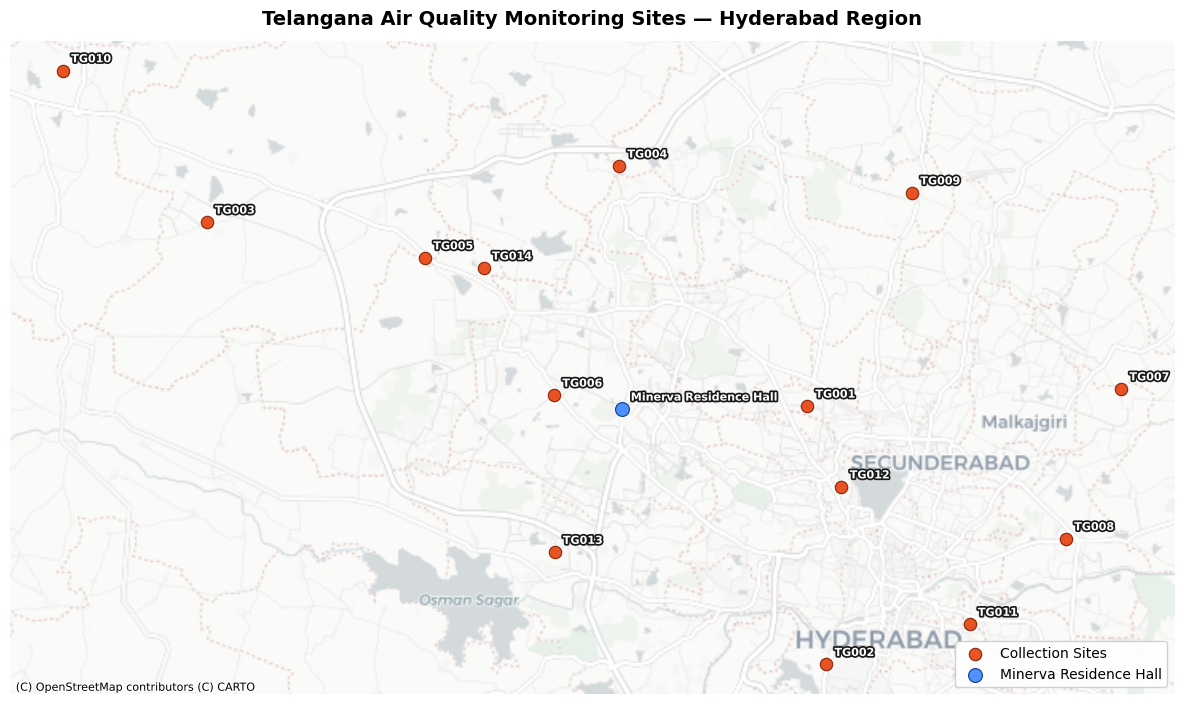

In [10]:
# Geopandas visualization of data collection sites.

collection_sites = [
    ("TG001", "Sanathnagar IE",      17.4569, 78.4436),
    ("TG002", "Zoo Park",            17.3507, 78.4518),
    ("TG003", "IDA Pashamylaram",    17.5325, 78.1849),
    ("TG004", "Bollaram Industrial", 17.5555, 78.3626),
    ("TG005", "ICRISAT Patancheru",  17.5178, 78.2790),
    ("TG006", "Central University",  17.4614, 78.3346),
    ("TG007", "ECIL Kapra",          17.4640, 78.5789),
    ("TG008", "Nacharam TSIIC",      17.4024, 78.5551),
    ("TG009", "Kompally Municipal",  17.5445, 78.4888),
    ("TG010", "IITH Kandi",          17.5947, 78.1230),
    ("TG011", "New Malakpet",        17.3672, 78.5136),
    ("TG012", "Somajiguda",          17.4237, 78.4584),
    ("TG013", "Kokapet",             17.3968, 78.3348),
    ("TG014", "Ramachandrapuram",    17.5136, 78.3043),
    ("Minerva Residence Hall", "AtHome Hotel", 17.455682, 78.364052),
]

labels, names, lats, lons = zip(*collection_sites)

# Build GeoDataFrame and reproject to Web Mercator (required by contextily)
gdf = gpd.GeoDataFrame(
    {"label": labels, "name": names},
    geometry=[Point(lon, lat) for lat, lon in zip(lats, lons)],
    crs="EPSG:4326",
).to_crs(epsg=3857)

sites = gdf[gdf["label"] != "Minerva Residence Hall"]
minerva = gdf[gdf["label"] == "Minerva Residence Hall"]

# Plotting
fig, ax = plt.subplots(figsize=(12, 10))

sites.plot(
    ax=ax,
    color="#E8400C",
    markersize=80,
    edgecolors="#7a1a00",
    linewidths=0.8,
    zorder=3,
    alpha=0.9,
    label="Collection Sites",
)
# Separate point plotting for the blue color
minerva.plot(
    ax=ax,
    color="#3A86FF",
    markersize=100,
    edgecolors="#003080",
    linewidths=0.8,
    zorder=4,
    alpha=0.9,
    label="Minerva Residence Hall",
)

# Label each point
for _, row in gdf.iterrows():
    txt = ax.annotate(
        row["label"],
        xy=(row.geometry.x, row.geometry.y),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=8,
        fontweight="bold",
        color="white",
        zorder=5,
    )
    txt.set_path_effects([
        pe.Stroke(linewidth=2.5, foreground="#1a1a1a"),
        pe.Normal(),
    ])

# Add basemap tiles — CartoDB Positron is clean and readable
ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Positron,
    zoom=11,
)

ax.set_axis_off()
ax.set_title(
    "Telangana Air Quality Monitoring Sites — Hyderabad Region",
    fontsize=14, fontweight="bold", pad=12,
)
ax.legend(loc="lower right", framealpha=0.9, fontsize=10)

plt.tight_layout()
plt.show()

In Session 5, we specifically learned how and when to use heatmaps. In class, we used heatmaps to show correlation between variables. Here, we used heatmaps in a different way, but still corresponding to it's correct usage: to compare concentrations. Comparing percentages allowed us to create this great visualization that allows for quick absorption of the important information. The 5th file appears to have the least amount of missing data as the whole row is the lightest colored, across the board. The 5th file, which still contains over 2,000 days of data, ended up being our choice for the cleanest, reliable dataset. We continued working with the 5th Hyderabad air pollution dataset.

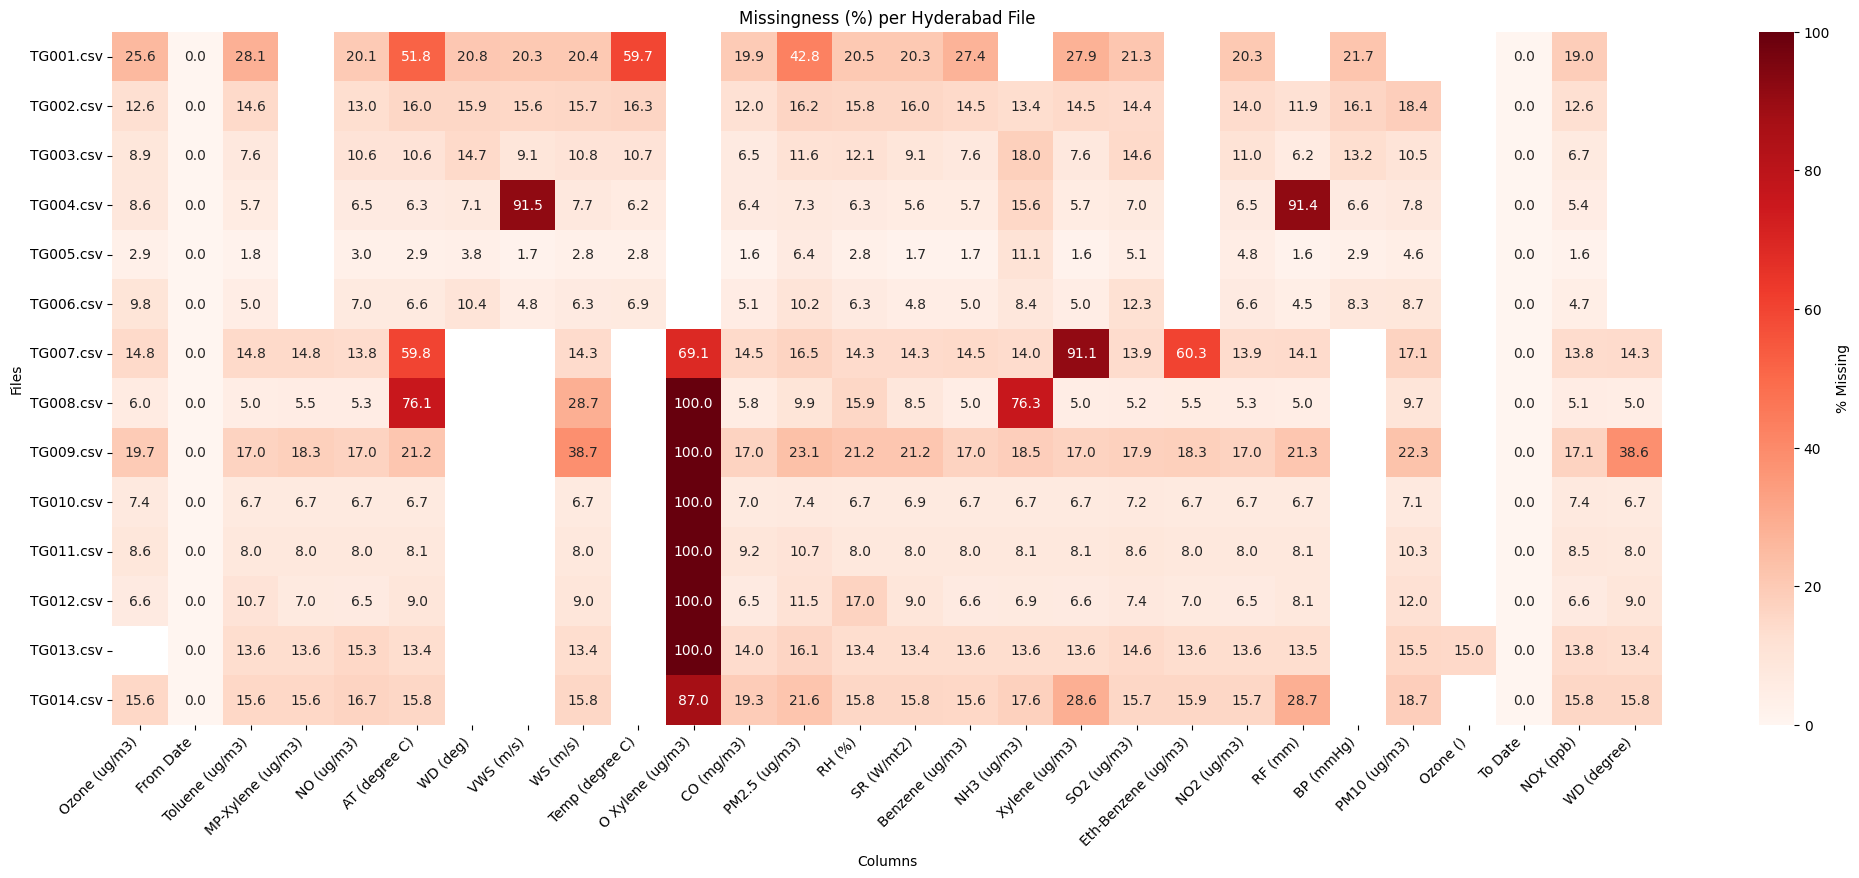

In [11]:
plt.figure(figsize=(25,9))
sns.heatmap(missingness_df, annot=True, fmt=".1f", cmap="Reds", cbar_kws={'label':'% Missing'})
plt.title("Missingness (%) per Hyderabad File")
plt.xlabel("Columns")
plt.ylabel("Files")
plt.xticks(rotation=45, ha='right')
plt.show()

Double-checking whether the files with the least percent of missing values contain all the needed columns, and checking whether the distribution of the PM2.5 value is very different.

In [12]:
folder = "/content/time-series-air-quality-data-of-india-2010-2023"

files_to_check = ["TG005.csv", "TG006.csv","TG008.csv", "TG010.csv"]

for fname in files_to_check:
    file_path = os.path.join(folder, fname)
    df = pd.read_csv(file_path)
    print(f"\nColumns in {fname}:")
    print(f"Number of columns: {len(df.columns)}")
    print('\n')
    # First check the distributions for just the dependent variable PM2.5
    print(df['PM2.5 (ug/m3)'].describe())
    print('\n')
    # Then for all variables
    print(df.describe())
    print(df.columns.tolist())


Columns in TG005.csv:
Number of columns: 23


count    49925.000000
mean        37.832227
std         24.919754
min          0.250000
25%         16.250000
50%         33.250000
75%         57.250000
max        173.000000
Name: PM2.5 (ug/m3), dtype: float64


       PM2.5 (ug/m3)  PM10 (ug/m3)    NO (ug/m3)   NO2 (ug/m3)     NOx (ppb)  \
count   49925.000000  50851.000000  51753.000000  50788.000000  52491.000000   
mean       37.832227     85.611833      3.927424     15.497715     11.091084   
std        24.919754     54.632249     11.032626     15.555194     13.088921   
min         0.250000      0.670000      0.030000      0.070000      0.000000   
25%        16.250000     39.000000      0.770000      4.770000      3.675000   
50%        33.250000     78.000000      1.500000     10.100000      6.730000   
75%        57.250000    125.000000      2.850000     21.200000     13.750000   
max       173.000000    663.500000    491.000000    207.130000    399.630000   

        NH3 (ug/m3

Dataset #5:
```
count    49925.000000
mean        37.832227
std         24.919754
min          0.250000
25%         16.250000
50%         33.250000
75%         57.250000
max        173.000000
Name: PM2.5 (ug/m3), dtype: float64
```



Dataset #6:
```
count    45271.000000
mean        34.266739
std         33.440363
min          0.250000
25%         15.000000
50%         29.250000
75%         48.250000
max        887.000000
Name: PM2.5 (ug/m3), dtype: float64
```

Dataset # 8:
```
count    6692.000000
mean       32.620663
std        20.951265
min         0.040000
25%        19.570000
50%        28.785000
75%        39.550000
max       327.520000
Name: PM2.5 (ug/m3), dtype: float64
```

Dataset #10:
```
count    6877.000000
mean       32.224975
std        13.934420
min         0.010000
25%        21.240000
50%        30.780000
75%        41.890000
max       163.700000
Name: PM2.5 (ug/m3), dtype: float64
```

#### Observations on dataset comparison

The total count of observations for datasets 8 and 10 are a fraction of the counts for datasets 5 and 6, even though missingness percent is similar. This means that datasets 5 and 6 are have far more data entries and are preferable for this reason.

The means & medians were quite similar across the board. Regarding outliers, dataset #6 has a very unrealistic maximum value. It is double the value measured during the worst ever air quality day, in Lahore, Pakistan. Although it is possible that another city with less overall air pollution could have a higher PM2.5 value, as this is just one measure of the frequently used AQI score, Hyderabad could not have truly experienced double Lahore's PM2.5 value. This extreme and implausible value for dataset #6 is also certainly skewing the dataset's distribution statistics, including inflating it's standard deviation value.

The standard deviations do differ between the datasets, ranging from 13 to 33. dataset #5 has a medium standard-deviation value in comparison with the other datasets. Despite this, dataset #5 has a low 25% quartile value and a high 75% quartile value without any extreme minimum or maximum values, like with datasets #6 and #8.

Beyond PM2.5, we conducted a careful investigation on the distributions of other variables, placing emphasis on environmental fluctuations between locations, such as temperature and wind speed. Between these 4 datasets, all environmental variables were very consistent, especially in median and mean values.

### Cleaning chosen dataset

TG005.csv seems like the best candidate from the 4 datasets explored above as it has very few missing values, has a wide temporal range, and no extreme outliers. The data was collected from an agro-research institute just 30 minutes north-west of the Minerva residence hall.

In [13]:
chosen_file = "TG005.csv"
file_path = os.path.join(folder, chosen_file)
chosen_df = pd.read_csv(file_path)

columns_to_keep = [
    'From Date', 'To Date', 'PM2.5 (ug/m3)', 'PM10 (ug/m3)', 'Temp (degree C)', 'RH (%)']

columns2017_2023 = chosen_df[columns_to_keep]

columns2017_2023.head()

from google.colab import files
df.to_csv("columns2017_2023.csv", index=False)
files.download("columns2017_2023.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Here, we took the file #5 data and reduced the date range to the first 2 months of 2023.
We also reworked the date time column to separate into date and hour of the day columns.
We also counted the number of missing data values per day, and identified days without missing data within this time range.

Finally, we visualized the resulting dataset that was structured by hour.

All of the above skills were learned in Zelda's Session (#9) on Time Series data. Just like how she taught us about rolling averages, we applied data smoothing here to join data by day rather than by hour. This had similar benefits to rolling averages plots.

In [14]:
# Create new dataset with data recorded during following period
recent_hyd_df = columns2017_2023[(columns2017_2023["From Date"] >= "2023-01-01 00:00:00") & (columns2017_2023["From Date"] < "2023-03-01 00:00:00")]

# Make sure "From Date" is datetime
recent_hyd_df["From Date"] = pd.to_datetime(recent_hyd_df["From Date"])

# Extract just the date (no time) into a helper column
recent_hyd_df["date"] = recent_hyd_df["From Date"].dt.date

# For each day, count NaNs in PM2.5 column only
nan_by_day = recent_hyd_df.groupby("date")["PM2.5 (ug/m3)"].apply(lambda x: x.isnull().sum())

print("PM2.5 NaNs per day:")
print(nan_by_day)

print("\nDays with zero PM2.5 NaNs:")
print(nan_by_day[nan_by_day == 0])

PM2.5 NaNs per day:
date
2023-01-01     0
2023-01-02     2
2023-01-03    12
2023-01-04     0
2023-01-05    10
2023-01-06     0
2023-01-07     0
2023-01-08     0
2023-01-09     0
2023-01-10     0
2023-01-11     0
2023-01-12     0
2023-01-13     0
2023-01-14     0
2023-01-15     0
2023-01-16     0
2023-01-17     0
2023-01-18     0
2023-01-19     0
2023-01-20     0
2023-01-21     1
2023-01-22     0
2023-01-23     0
2023-01-24     0
2023-01-25     0
2023-01-26     0
2023-01-27     0
2023-01-28     0
2023-01-29     0
2023-01-30     0
2023-01-31     0
2023-02-01     0
2023-02-02     0
2023-02-03     0
2023-02-04     0
2023-02-05     0
2023-02-06     0
2023-02-07     0
2023-02-08     0
2023-02-09     6
2023-02-10     0
2023-02-11     5
2023-02-12     0
2023-02-13     0
2023-02-14     0
2023-02-15     0
2023-02-16     0
2023-02-17     0
2023-02-18     0
2023-02-19     0
2023-02-20     0
2023-02-21     0
2023-02-22     0
2023-02-23     0
2023-02-24     0
2023-02-25     0
2023-02-26     0
2023-0

/tmp/ipykernel_10152/215552552.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  recent_hyd_df["From Date"] = pd.to_datetime(recent_hyd_df["From Date"])
/tmp/ipykernel_10152/215552552.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  recent_hyd_df["date"] = recent_hyd_df["From Date"].dt.date


In [15]:
# Drop columns besides 'PM2.5 (ug/m3)', and shrink data by date
ready_hyd_df = recent_hyd_df[["From Date", "To Date", "PM2.5 (ug/m3)"]]
ready_hyd_df["date"] = pd.to_datetime(ready_hyd_df["From Date"]).dt.date
ready_hyd_df["hour"] = pd.to_datetime(ready_hyd_df["From Date"]).dt.hour
ready_hyd_df = ready_hyd_df.rename(columns={"From Date": "From DateTime"})

ready_hyd_df.head(50)

/tmp/ipykernel_10152/1288430520.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ready_hyd_df["date"] = pd.to_datetime(ready_hyd_df["From Date"]).dt.date
/tmp/ipykernel_10152/1288430520.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ready_hyd_df["hour"] = pd.to_datetime(ready_hyd_df["From Date"]).dt.hour


,From DateTime,To Date,PM2.5 (ug/m3),date,hour
51168,2023-01-01 00:00:00,2023-01-01 01:00:00,82.25,2023-01-01,0
51169,2023-01-01 01:00:00,2023-01-01 02:00:00,75.25,2023-01-01,1
51170,2023-01-01 02:00:00,2023-01-01 03:00:00,78.75,2023-01-01,2
51171,2023-01-01 03:00:00,2023-01-01 04:00:00,80.25,2023-01-01,3
51172,2023-01-01 04:00:00,2023-01-01 05:00:00,84.75,2023-01-01,4
51173,2023-01-01 05:00:00,2023-01-01 06:00:00,77.00,2023-01-01,5
51174,2023-01-01 06:00:00,2023-01-01 07:00:00,71.33,2023-01-01,6
51175,2023-01-01 07:00:00,2023-01-01 08:00:00,65.75,2023-01-01,7
51176,2023-01-01 08:00:00,2023-01-01 09:00:00,65.75,2023-01-01,8
51177,2023-01-01 09:00:00,2023-01-01 10:00:00,65.75,2023-01-01,9


In [16]:
# Checking quality of data
print(ready_hyd_df.describe())

# Counting N/A values
print(ready_hyd_df.isnull().sum())

                       From DateTime  PM2.5 (ug/m3)         hour
count                           1416    1380.000000  1416.000000
mean   2023-01-30 11:30:00.000000256      61.469370    11.500000
min              2023-01-01 00:00:00      16.750000     0.000000
25%              2023-01-15 17:45:00      48.187500     5.750000
50%              2023-01-30 11:30:00      64.500000    11.500000
75%              2023-02-14 05:15:00      76.750000    17.250000
max              2023-02-28 23:00:00      86.750000    23.000000
std                              NaN      17.422962     6.924632
From DateTime     0
To Date           0
PM2.5 (ug/m3)    36
date              0
hour              0
dtype: int64


### Visualizing Chosen Dataset

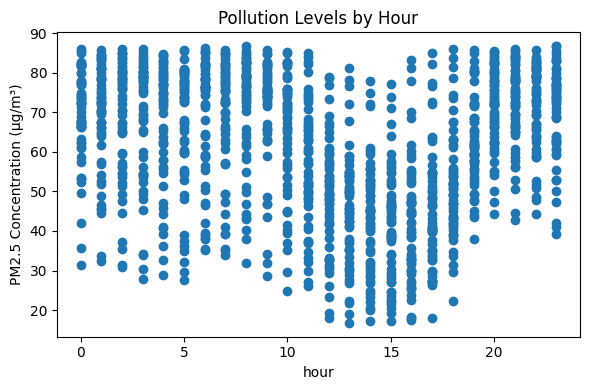

In [17]:
plt.figure(figsize=(6,4))

plt.scatter(ready_hyd_df["hour"], ready_hyd_df["PM2.5 (ug/m3)"])

plt.xlabel("hour")
plt.ylabel("PM2.5 Concentration (µg/m³)")
plt.title("Pollution Levels by Hour")

plt.tight_layout()
plt.show()

We specifically studied box plots as a focus in our second breakout of *Session 5: EDA and Advanced Data Viz*.

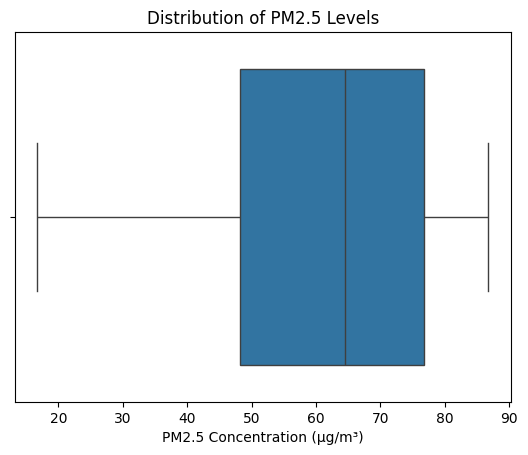

In [18]:
#Checked for outliers with this boxplot

sns.boxplot(x=ready_hyd_df["PM2.5 (ug/m3)"])

plt.xlabel("PM2.5 Concentration (µg/m³)")
plt.title("Distribution of PM2.5 Levels")

plt.show()

Now moving on from using a 2 month period to using all the years included in file 5, in order to include missing values and learn how to repair the messy data rather than ignore it.

In [19]:
# Make sure "From Date" is datetime
columns2017_2023["From Date"] = pd.to_datetime(columns2017_2023["From Date"])

# Extract just the date (no time) into a helper column
columns2017_2023["date"] = columns2017_2023["From Date"].dt.date

# For each day, count NaNs in PM2.5 column only
nan_by_day = columns2017_2023.groupby("date")["PM2.5 (ug/m3)"].apply(lambda x: x.isnull().sum())

print("PM2.5 NaNs per day:")
print(nan_by_day)

print("\nDays with zero PM2.5 NaNs:")
print(nan_by_day[nan_by_day == 0])

PM2.5 NaNs per day:
date
2017-03-01    0
2017-03-02    0
2017-03-03    0
2017-03-04    0
2017-03-05    0
             ..
2023-03-27    0
2023-03-28    0
2023-03-29    2
2023-03-30    0
2023-03-31    0
Name: PM2.5 (ug/m3), Length: 2222, dtype: int64

Days with zero PM2.5 NaNs:
date
2017-03-01    0
2017-03-02    0
2017-03-03    0
2017-03-04    0
2017-03-05    0
             ..
2023-03-26    0
2023-03-27    0
2023-03-28    0
2023-03-30    0
2023-03-31    0
Name: PM2.5 (ug/m3), Length: 1764, dtype: int64


/tmp/ipykernel_10152/3490594852.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  columns2017_2023["From Date"] = pd.to_datetime(columns2017_2023["From Date"])
/tmp/ipykernel_10152/3490594852.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  columns2017_2023["date"] = columns2017_2023["From Date"].dt.date


In [20]:
# Drop columns besides 'PM2.5 (ug/m3)', and shrink data by date
# Start with the base columns for full_hyd_df
full_hyd_df = columns2017_2023[["From Date", "To Date", "PM2.5 (ug/m3)"]]
full_hyd_df["date"] = pd.to_datetime(full_hyd_df["From Date"]).dt.date
full_hyd_df["hour"] = pd.to_datetime(full_hyd_df["From Date"]).dt.hour
full_hyd_df = full_hyd_df[[ "PM2.5 (ug/m3)", "date", "hour"]]
#full_hyd_df = full_hyd_df.rename(columns={"From Date": "From DateTime"})

full_hyd_df.head(50)

/tmp/ipykernel_10152/2843326037.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  full_hyd_df["date"] = pd.to_datetime(full_hyd_df["From Date"]).dt.date
/tmp/ipykernel_10152/2843326037.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  full_hyd_df["hour"] = pd.to_datetime(full_hyd_df["From Date"]).dt.hour


,PM2.5 (ug/m3),date,hour
0,65.75,2017-03-01,0
1,63.50,2017-03-01,1
2,67.00,2017-03-01,2
3,65.00,2017-03-01,3
4,66.25,2017-03-01,4
5,61.00,2017-03-01,5
6,60.50,2017-03-01,6
7,64.75,2017-03-01,7
8,90.00,2017-03-01,8
9,105.50,2017-03-01,9


In [21]:
print(f"Missing values in PM2.5 (ug/m3): {full_hyd_df["PM2.5 (ug/m3)"].isnull().sum()}")
print(f"Original mean (before adding NaN): {full_hyd_df["PM2.5 (ug/m3)"].mean():.2f}")
print(f"Original median: {full_hyd_df["PM2.5 (ug/m3)"].median():.2f}")

Missing values in PM2.5 (ug/m3): 3403
Original mean (before adding NaN): 37.83
Original median: 33.25


Now that the full data is back and cleaned to remove all unnecessary columns,
we are ready to deal with the same 6.4% of missing PM2.5 data from last time.

In Laryssa's Session 4 on dealing with missing data, she taught us four of the most common techniques for dealing with missing data. These were, Deletion, Mean imputation, Median imputation, & KNN imputation. Due to the strength of having several datasets over the same time period, we also have data from neighboring meteorological data collection sites that could be adapted to be used in place of file #5's data, but we will save the implemention of this more creative idea for the final assignment. For this assignment, we revisited Laryssa's Session 4 2nd breakout's jupyter notebook to learn of the differences between her techniques and how they would compare to imputing data from another file.

Deletion

In [22]:
df_deleted = full_hyd_df.dropna()

print(f"Rows remaining: {len(df_deleted)} (lost {len(full_hyd_df) - len(df_deleted)} rows)")
print(f"Mean priors_count: {df_deleted["PM2.5 (ug/m3)"].mean():.2f}")

Rows remaining: 49925 (lost 3403 rows)
Mean priors_count: 37.83


Mean imputation

In [23]:
df_mean = full_hyd_df.copy()
mean_val = df_mean["PM2.5 (ug/m3)"].mean()
df_mean["PM2.5 (ug/m3)"].fillna(mean_val, inplace=True)

print(f"Rows remaining: {len(df_mean)}")
print(f"Imputed with mean = {mean_val:.2f}")
print(f"New mean: {df_mean["PM2.5 (ug/m3)"].mean():.2f}")

Rows remaining: 53328
Imputed with mean = 37.83
New mean: 37.83


/tmp/ipykernel_10152/3319599872.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_mean["PM2.5 (ug/m3)"].fillna(mean_val, inplace=True)


Median imputation

In [24]:
df_median = full_hyd_df.copy()
median_val = df_median["PM2.5 (ug/m3)"].median()
df_median["PM2.5 (ug/m3)"].fillna(median_val, inplace=True)

print(f"Rows remaining: {len(df_median)}")
print(f"Imputed with median = {median_val:.2f}")
print(f"New mean: {df_median["PM2.5 (ug/m3)"].mean():.2f}")

Rows remaining: 53328
Imputed with median = 33.25
New mean: 37.54


/tmp/ipykernel_10152/254639638.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_median["PM2.5 (ug/m3)"].fillna(median_val, inplace=True)


KNN imputation

In [25]:
from sklearn.impute import KNNImputer

'''
I converted date to a numerical format that the KNN imputer can use, rather than leaving
out the date column entirely and having the imputer rely only on hour of the day.

This way, a gap on 2023-01-03 will borrow from 2023-01-01 or 2023-01-04 at the same hour,
rather than from a random Tuesday in July that happened to have the same hour pattern.

'''
# Date translation.
full_hyd_df['date_ordinal'] = pd.to_datetime(full_hyd_df['date']).map(pd.Timestamp.toordinal)

# Doesn't permit to use 'date' column.
features = ['PM2.5 (ug/m3)', 'date_ordinal', 'hour']

df_knn = full_hyd_df[features].copy()

imputer = KNNImputer(n_neighbors=5)
df_knn_values = imputer.fit_transform(df_knn)
df_knn = pd.DataFrame(df_knn_values, columns=df_knn.columns)


print(f"Rows remaining: {len(df_knn)}")
print(f"New mean: {df_knn["PM2.5 (ug/m3)"].mean():.2f}")

Rows remaining: 53328
New mean: 37.20


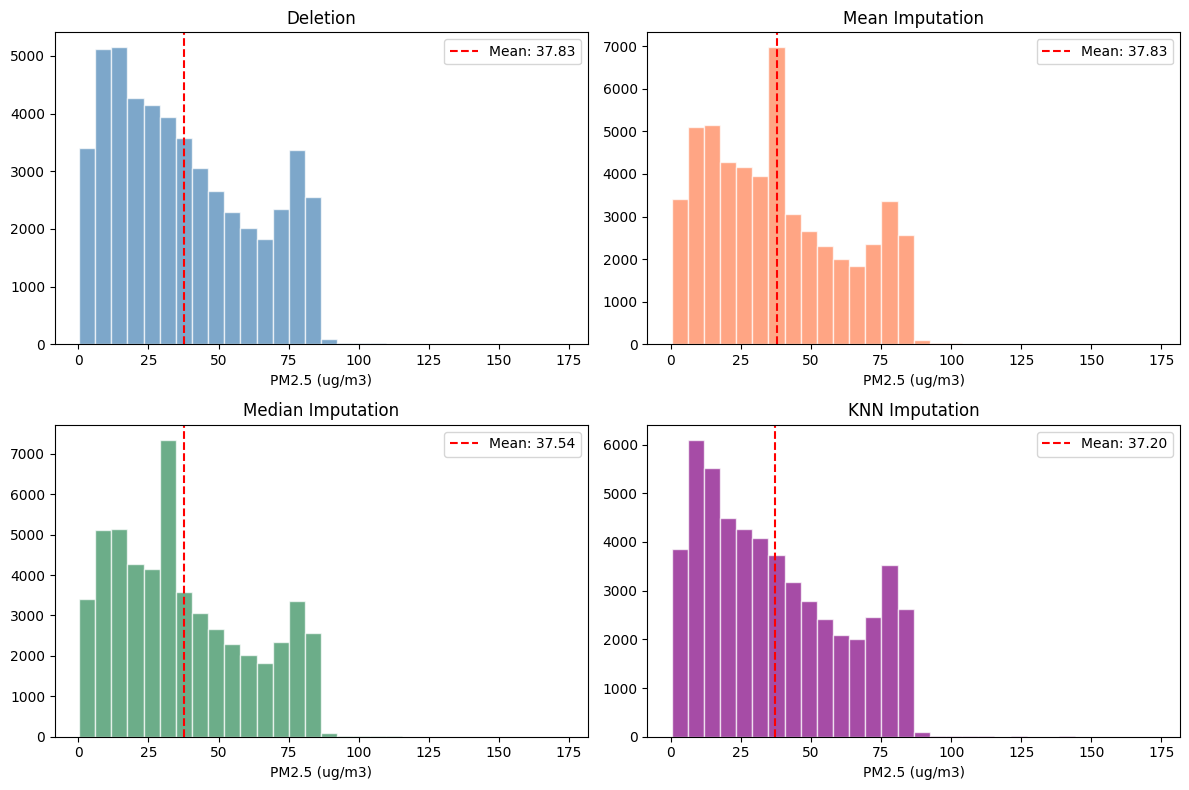

Summary:
  Deletion:    n=49,925, mean=37.83
  Mean Imp:    n=53,328, mean=37.83
  Median Imp:  n=53,328, mean=37.54
  KNN Imp:     n=53,328, mean=37.20


In [26]:
# Side-by-side comparison
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

methods = [
    (df_deleted['PM2.5 (ug/m3)'], 'Deletion', 'steelblue'),
    (df_mean['PM2.5 (ug/m3)'], 'Mean Imputation', 'coral'),
    (df_median['PM2.5 (ug/m3)'], 'Median Imputation', 'seagreen'),
    (df_knn['PM2.5 (ug/m3)'], 'KNN Imputation', 'purple')
]

for ax, (data, title, color) in zip(axes.flat, methods):
    ax.hist(data, bins=30, color=color, edgecolor='white', alpha=0.7)
    ax.axvline(data.mean(), color='red', linestyle='--', label=f'Mean: {data.mean():.2f}')
    ax.set_title(title)
    ax.set_xlabel('PM2.5 (ug/m3)')
    ax.legend()

plt.tight_layout()
plt.show()

print("Summary:")
print(f"  Deletion:    n={len(df_deleted):,}, mean={df_deleted['PM2.5 (ug/m3)'].mean():.2f}")
print(f"  Mean Imp:    n={len(df_mean):,}, mean={df_mean['PM2.5 (ug/m3)'].mean():.2f}")
print(f"  Median Imp:  n={len(df_median):,}, mean={df_median['PM2.5 (ug/m3)'].mean():.2f}")
print(f"  KNN Imp:     n={len(df_knn):,}, mean={df_knn['PM2.5 (ug/m3)'].mean():.2f}")

### KNN imputed dataset pattern identification

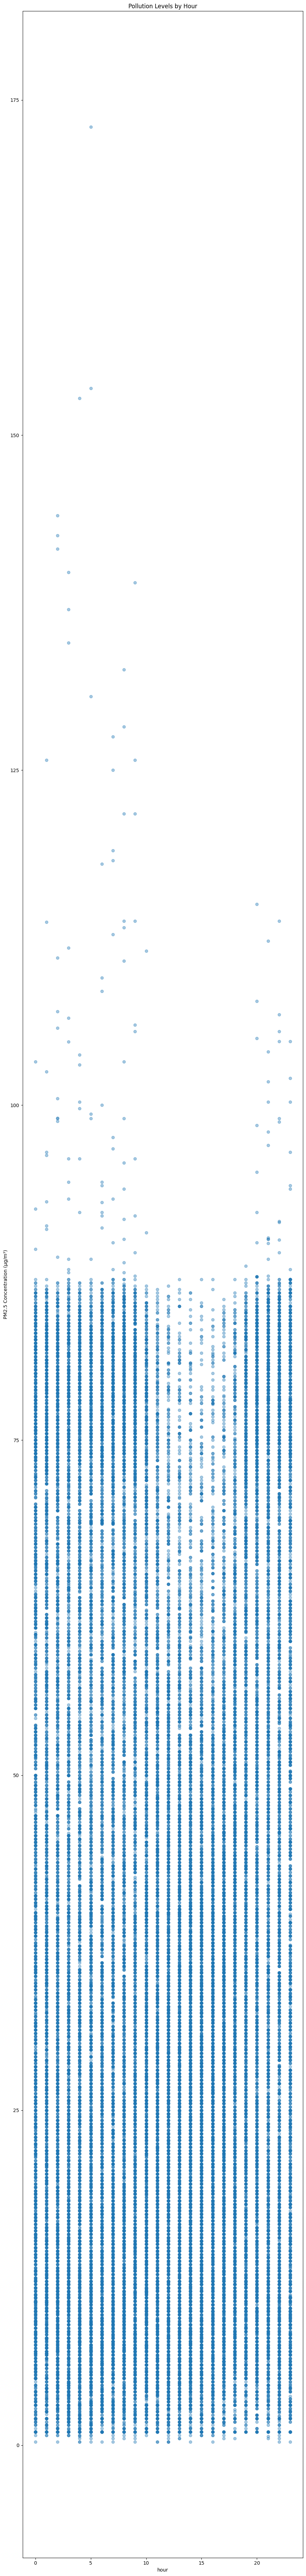

In [40]:
# Original 2-month scatterplot, poorly adapted to this quantity of data points.
# Improved visualizations can be found below


plt.figure(figsize=(9,75))

plt.scatter(df_knn["hour"], df_knn["PM2.5 (ug/m3)"], alpha=0.4)

plt.xlabel("hour")
plt.ylabel("PM2.5 Concentration (µg/m³)")
plt.title("Pollution Levels by Hour")

plt.tight_layout()
plt.show()

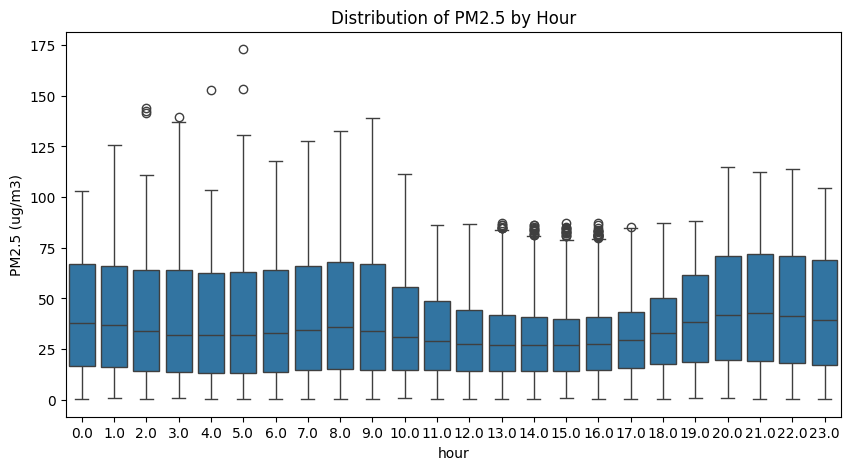

In [42]:
plt.figure(figsize=(10,5))
sns.boxplot(x="hour", y="PM2.5 (ug/m3)", data=df_knn)

plt.title("Distribution of PM2.5 by Hour")
plt.show()

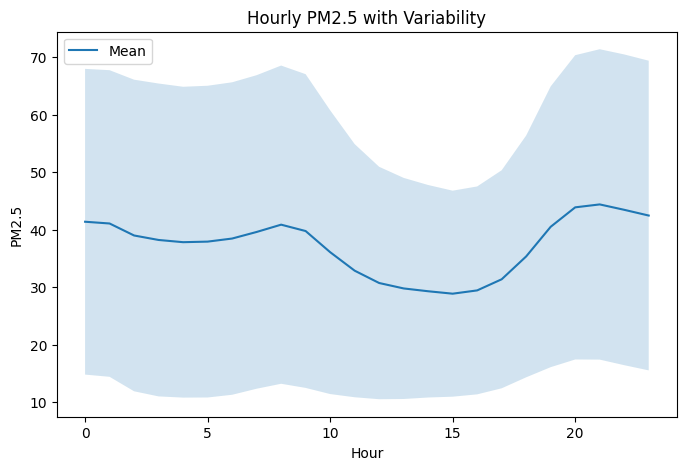

In [37]:
hourly = df_knn.groupby("hour")["PM2.5 (ug/m3)"]
mean = hourly.mean()
std = hourly.std()

plt.figure(figsize=(8,5))
plt.plot(mean.index, mean.values, label="Mean")
plt.fill_between(mean.index, mean-std, mean+std, alpha=0.2)

plt.xlabel("Hour")
plt.ylabel("PM2.5")
plt.title("Hourly PM2.5 with Variability")
plt.legend()
plt.show()

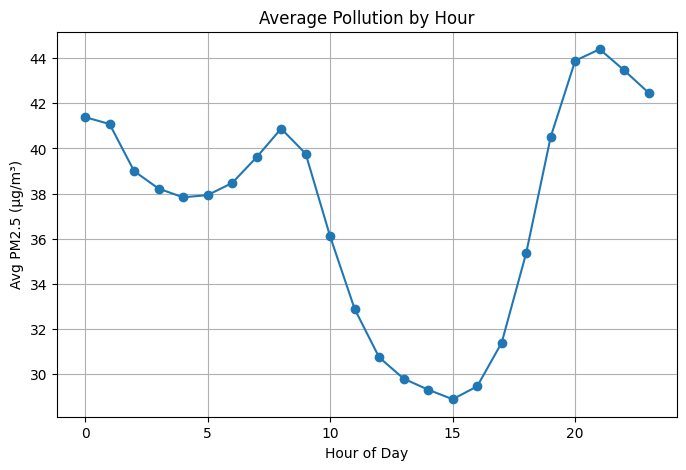

In [43]:
hourly_avg = df_knn.groupby("hour")["PM2.5 (ug/m3)"].mean()

plt.figure(figsize=(8,5))
plt.plot(hourly_avg.index, hourly_avg.values, marker='o')

plt.xlabel("Hour of Day")
plt.ylabel("Avg PM2.5 (µg/m³)")
plt.title("Average Pollution by Hour")
plt.grid(True)
plt.show()

### Do we find the daily fluctuation in PM 2.5 concentrations?


Let us visualize the daily fluctuations of PM2.5 concentration by generating line plots for a randomly selected three-day period from the `df_knn` DataFrame.

## Randomly Select Multi-Day Period


In [27]:
import random
from datetime import timedelta

# 1. Convert the 'date_ordinal' column in df_knn back to datetime objects
df_knn['actual_date'] = df_knn['date_ordinal'].apply(lambda x: pd.Timestamp.fromordinal(int(x)))

# 2. Extract all unique dates from the 'actual_date' column
unique_dates = pd.Series(df_knn['actual_date'].unique()).sort_values().reset_index(drop=True)

# Prompt the user for the number of consecutive days they want to analyze
num_days_input = input("Enter the number of consecutive days to analyze (e.g., 3 for 3 days): ")
while not num_days_input.isdigit() or int(num_days_input) < 1:
    num_days_input = input("Invalid input. Please enter a positive integer for the number of days: ")
num_days = int(num_days_input)

# 3. Randomly select a starting date for a consecutive num_days sequence
valid_start_dates = []
if num_days > 0:
    for i in range(len(unique_dates) - num_days + 1):
        current_date = unique_dates[i]
        # Check if num_days-1 consecutive days exist after the current_date
        all_consecutive_days_exist = True
        for j in range(1, num_days):
            if current_date + timedelta(days=j) not in unique_dates.values:
                all_consecutive_days_exist = False
                break
        if all_consecutive_days_exist:
            valid_start_dates.append(current_date)

if not valid_start_dates:
    raise ValueError(f"No valid {num_days}-day consecutive period found in the data.")

random_start_date = random.choice(valid_start_dates)

# 4. Store the num_days selected dates
selected_dates = [
    random_start_date + timedelta(days=k) for k in range(num_days)
]

print(f"Selected {num_days}-day period starting from: {random_start_date.date()} and ending on {selected_dates[-1].date()}")
print(f"All selected dates: {selected_dates}")

Enter the number of consecutive days to analyze (e.g., 3 for 3 days): 7
Selected 7-day period starting from: 2022-06-23 and ending on 2022-06-29
All selected dates: [Timestamp('2022-06-23 00:00:00'), Timestamp('2022-06-24 00:00:00'), Timestamp('2022-06-25 00:00:00'), Timestamp('2022-06-26 00:00:00'), Timestamp('2022-06-27 00:00:00'), Timestamp('2022-06-28 00:00:00'), Timestamp('2022-06-29 00:00:00')]


Now that the `selected_dates` are identified, the next step is to filter the `df_knn` DataFrame to include only the data corresponding to these three dates. This will prepare the data for visualization of daily fluctuations.



In [28]:
selected_days_df = df_knn[df_knn['actual_date'].isin(selected_dates)].copy()

print("First 5 rows of the filtered DataFrame for the selected three-day period:")
print(selected_days_df.head())
print(f"\nShape of the three_day_df: {selected_days_df.shape}")

First 5 rows of the filtered DataFrame for the selected three-day period:
       PM2.5 (ug/m3)  date_ordinal  hour actual_date
46560            7.5      738329.0   0.0  2022-06-23
46561            5.0      738329.0   1.0  2022-06-23
46562            2.0      738329.0   2.0  2022-06-23
46563            2.0      738329.0   3.0  2022-06-23
46564            1.8      738329.0   4.0  2022-06-23

Shape of the three_day_df: (168, 4)


To visualize the daily fluctuations, we created line plots for the selected days, showing PM2.5 concentration against the hour of the day.


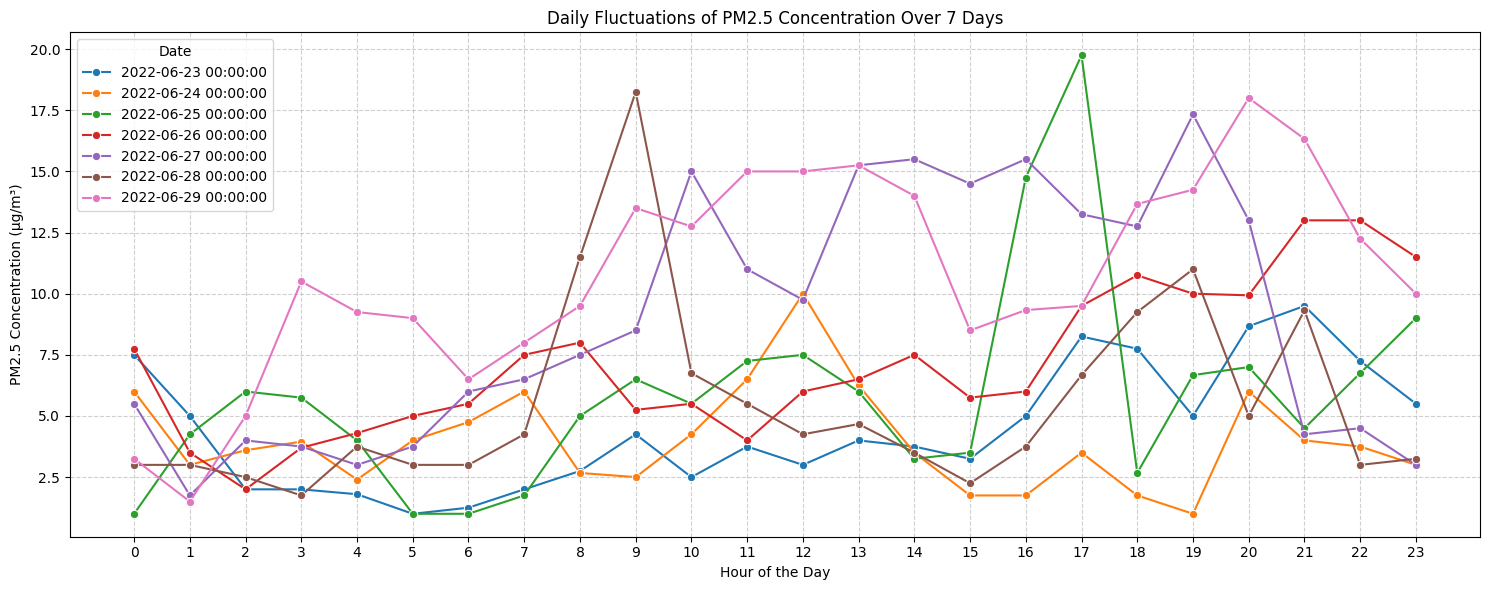

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 6))
sns.lineplot(data=selected_days_df, x='hour', y='PM2.5 (ug/m3)', hue='actual_date', marker='o')

plt.title(f'Daily Fluctuations of PM2.5 Concentration Over {num_days} Days')
plt.xlabel('Hour of the Day')
plt.ylabel('PM2.5 Concentration (µg/m³)')
plt.xticks(range(0, 24)) # Ensure all hours are shown on x-axis
plt.legend(title='Date')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
